# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from shapely.wkt import loads as wkt_loads
from pathlib import Path
from netCDF4 import Dataset

# Looking at examples

In [3]:
# Directory where the SAR data has been downloaded
root_dir = Path("/home/cdauvill/scratch/data/motif/raw/sar_cyclobs/")
# CyclObs API CSV metadata file
acq_csv = root_dir / "sar_acquisitions_metadata.csv"
acq_df = pd.read_csv(acq_csv)
acq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2737 entries, 0 to 2736
Data columns (total 67 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   data_url                      2737 non-null   object 
 1   mission                       2737 non-null   object 
 2   mission_short                 2737 non-null   object 
 3   instrument                    2737 non-null   object 
 4   instrument_short              2737 non-null   object 
 5   acquisition_start_time        2737 non-null   object 
 6   bounding_box                  2737 non-null   object 
 7   dist_eye_centroid             2737 non-null   float64
 8   eye_in_acq                    2737 non-null   bool   
 9   coloc_file                    0 non-null      float64
 10  sid                           2737 non-null   object 
 11  track_source                  2737 non-null   object 
 12  track_file                    2737 non-null   object 
 13  cyc

In [4]:
# Retrieve the name of the files from the "data_url" column
acq_df["file_name"] = acq_df["data_url"].apply(lambda x: x.split("/")[-1])
acq_df['file_name'].head()

0    rcm1-sc100ma-owi-cm-20220926t112558-20220926t1...
1    rcm1-sc100ma-owi-cm-20220927t113348-20220927t1...
2    rcm1-sc50ma-owi-cm-20200812t014959-20200812t01...
3    rcm1-sc50ma-owi-cm-20210419t093250-20210419t09...
4    rcm1-sc50ma-owi-cm-20210420t094105-20210420t09...
Name: file_name, dtype: object

In [5]:
# Deduce a list of paths on disk to the netCDF files
nc_files = [root_dir / fname for fname in acq_df['file_name'].tolist()]
print(f"Found {len(nc_files)} netCDF files.")

Found 2737 netCDF files.


Let's look at one of the netCDF files:

In [6]:
ds = xr.open_dataset(nc_files[0])
ds

<xarray.Dataset> Size: 76MB
Dimensions:                    (time: 1, lat: 781, lon: 693)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2022-09-26T11:27:02
  * lat                        (lat) float64 6kB 23.68 23.67 ... 16.47 16.46
  * lon                        (lon) float64 6kB -86.35 -86.34 ... -79.96 -79.95
Data variables: (12/21)
    ancillary_wind_direction   (time, lat, lon) float64 4MB ...
    wind_from_direction_co     (time, lat, lon) float64 4MB ...
    nrcs_cross                 (time, lat, lon) float64 4MB ...
    nesz_cross_flattened       (time, lat, lon) float64 4MB ...
    nrcs_co                    (time, lat, lon) float64 4MB ...
    mask_flag                  (time, lat, lon) float32 2MB ...
    ...                         ...
    elevation_angle            (time, lat, lon) float64 4MB ...
    wind_from_direction        (time, lat, lon) float64 4MB ...
    heterogeneity_mask         (time, lat, lon) float64 4MB ...
    wind_speed_co              (time, lat, lon) float64 4MB ...
    wind_from_direction_cross  (time, lat, lon) float64 4MB ...
    spatial_ref                int64 8B ...
Attributes: (12/18)
    Conventions:                CF-1.6
    title:                      SAR ocean surface wind field
    institution:                IFREMER/CLS
    reference:                  Mouche Alexis, Chapron Bertrand, Knaff John, ...
    measurementDate:            2022-09-26T11:27:02Z
    nclight_processor_version:  1.0.10
    ...                         ...
    xsarsea_version:            2.0
    grdwindinversion_version:   0.3.9
    gmf:                        gmf_cmod5n, gmf_rcm_v4
    ancillary_source:           /home/datawork-cersat-public/provider/ecmwf/f...
    winddir_convention:         meteorological
    coverage:                   707km * 533km (line * sample )

The main variable we are interested in th ```wind_speed```:

In [7]:
ds['wind_speed']

<xarray.DataArray 'wind_speed' (time: 1, lat: 781, lon: 693)> Size: 4MB
[541233 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2022-09-26T11:27:02
  * lat      (lat) float64 6kB 23.68 23.67 23.66 23.65 ... 16.48 16.47 16.46
  * lon      (lon) float64 6kB -86.35 -86.34 -86.33 ... -79.97 -79.96 -79.95
Attributes:
    description:  Wind speed inverted from model gmf_cmod5n (VV) & gmf_rcm_v4...
    units:        m/s
    long_name:    Ocean 10m Wind speed from co- and cross- polarization

In [8]:
def show_sar_image(nc_file: str):
    """Load and display a SAR image from a netCDF file."""
    ds = xr.open_dataset(nc_file)
    sar_data = ds['wind_speed'][0]
    plt.figure(figsize=(10, 8))
    plt.imshow(sar_data, cmap='viridis')
    plt.title(f"SAR Image from {nc_file.name}")
    plt.colorbar(label='Backscatter')

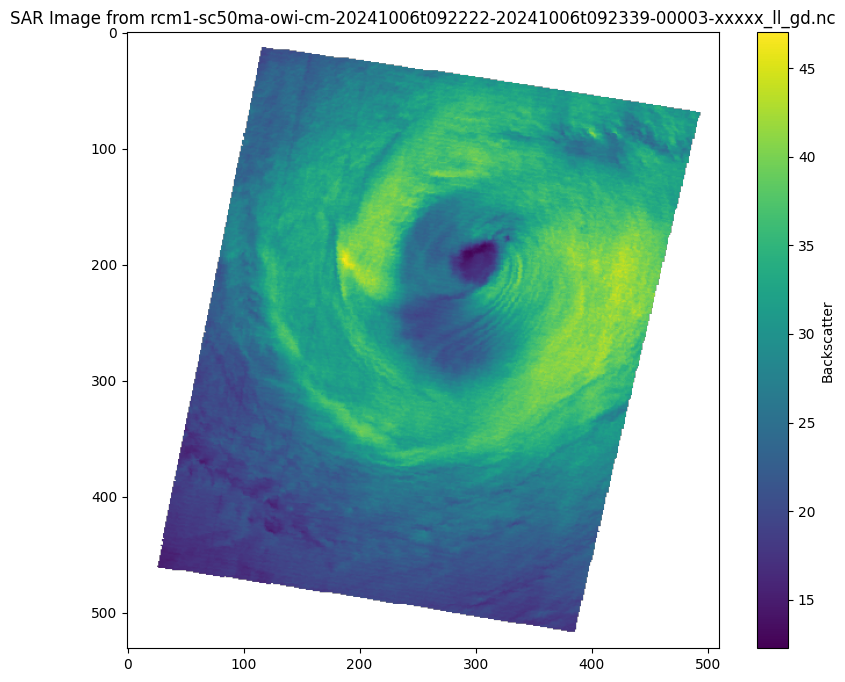

In [16]:
show_sar_image(nc_files[45])

In [10]:
ds['mask_flag']

<xarray.DataArray 'mask_flag' (time: 1, lat: 781, lon: 693)> Size: 2MB
[541233 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2022-09-26T11:27:02
  * lat      (lat) float64 6kB 23.68 23.67 23.66 23.65 ... 16.48 16.47 16.46
  * lon      (lon) float64 6kB -86.35 -86.34 -86.33 ... -79.97 -79.96 -79.95
Attributes:
    long_name:      Mask of data
    description:    Mask of data
    valid_range:    [0 3]
    flag_values:    [0 1 2 3]
    flag_meanings:  valid land ice no_valid